# EDA — LUNA16: Nódulos Pulmonares en CT de Tórax

**Proyecto:** MoE Medical Image Classification — Expert 3 (Detección de Nódulos Pulmonares)  
**Dataset:** LUNA16 (LUng Nodule Analysis 2016) — derivado de LIDC-IDRI  
**Tarea:** Clasificación binaria — nódulo (1) vs no-nódulo (0)  
**Anatomía:** Tomografía computarizada (CT) de **tórax** con caja torácica visible  

> **Nota W-03 (2026-04-02):** Se removieron 1.839 parches residuales de `train/` que
> correspondían a `seriesuid` de val/test (fuga de datos detectada por auditoría ARGOS).
> El script `fix_luna_leakage.py` eliminó los parches afectados el 2026-04-02.
> **Este EDA refleja el estado post-corrección.**

Este notebook explora la estructura del dataset LUNA16, la distribución de clases,
propiedades de los volúmenes CT, parches pre-extraídos, y valida el pipeline de
preprocesado antes del entrenamiento.

## Sección 0 — Configuración e Importaciones

In [135]:
import os
import sys
import json
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import SimpleITK as sitk
    HAS_SITK = True
    print(f'SimpleITK version: {sitk.Version.VersionString()}')
except ImportError:
    HAS_SITK = False
    print('SimpleITK not available — CT volume inspection will be skipped.')

try:
    import torch
    import torch.nn.functional as F
    HAS_TORCH = True
    print(f'PyTorch version: {torch.__version__}')
except ImportError:
    HAS_TORCH = False
    print('PyTorch not available — pipeline simulation will use numpy/scipy fallback.')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

print('Imports OK')

SimpleITK version: 2.5.3
PyTorch version: 2.10.0+cpu
Imports OK


### Definición de rutas del proyecto

Todas las rutas son relativas al directorio base del proyecto.

In [136]:
# ── Project paths ────────────────────────────────────────────────
BASE_DIR = Path('/mnt/hdd/datasets/carlos_andres_ferro/proyecto_2')
DATASET_DIR = BASE_DIR / 'datasets' / 'luna_lung_cancer'
CT_VOLUMES_DIR = DATASET_DIR / 'ct_volumes'
PATCHES_DIR = DATASET_DIR / 'patches'
CANDIDATES_V2_CSV = DATASET_DIR / 'candidates_V2' / 'candidates_V2.csv'
ANNOTATIONS_CSV = DATASET_DIR / 'annotations.csv'
EVAL_ANNOTATIONS_CSV = DATASET_DIR / 'evaluationScript' / 'evaluationScript' / 'annotations' / 'annotations.csv'
EVAL_ANNOTATIONS_EXCLUDED_CSV = DATASET_DIR / 'evaluationScript' / 'evaluationScript' / 'annotations' / 'annotations_excluded.csv'
SEG_LUNGS_DIR = DATASET_DIR / 'seg-lungs-LUNA16' / 'seg-lungs-LUNA16'
SPLITS_JSON = DATASET_DIR / 'luna_splits.json'
EXTRACTION_REPORT = PATCHES_DIR / 'extraction_report.json'

# ── Output directory for figures ────────────────────────────────
FIGURES_DIR = BASE_DIR / 'src' / 'notebooks' / 'luna_lung_cancer' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Verify critical paths exist
critical_paths = {
    'Dataset root': DATASET_DIR,
    'CT volumes': CT_VOLUMES_DIR,
    'Patches': PATCHES_DIR,
    'Candidates V2 CSV': CANDIDATES_V2_CSV,
    'Annotations CSV': ANNOTATIONS_CSV,
    'Splits JSON': SPLITS_JSON,
}

print('Path verification:')
print('=' * 60)
all_ok = True
for name, path in critical_paths.items():
    exists = path.exists()
    status = '  OK' if exists else 'MISSING'
    print(f'  [{status}] {name}')
    print(f'         {path}')
    if not exists:
        all_ok = False
print('=' * 60)
print('All critical paths exist.' if all_ok else 'WARNING: Some paths are missing!')

Path verification:
  [  OK] Dataset root
         /mnt/hdd/datasets/carlos_andres_ferro/proyecto_2/datasets/luna_lung_cancer
  [  OK] CT volumes
         /mnt/hdd/datasets/carlos_andres_ferro/proyecto_2/datasets/luna_lung_cancer/ct_volumes
  [  OK] Patches
         /mnt/hdd/datasets/carlos_andres_ferro/proyecto_2/datasets/luna_lung_cancer/patches
  [  OK] Candidates V2 CSV
         /mnt/hdd/datasets/carlos_andres_ferro/proyecto_2/datasets/luna_lung_cancer/candidates_V2/candidates_V2.csv
  [  OK] Annotations CSV
         /mnt/hdd/datasets/carlos_andres_ferro/proyecto_2/datasets/luna_lung_cancer/annotations.csv
  [  OK] Splits JSON
         /mnt/hdd/datasets/carlos_andres_ferro/proyecto_2/datasets/luna_lung_cancer/luna_splits.json
All critical paths exist.


---
## Sección 1 — Inventario del Dataset

Conteo de volúmenes CT (archivos `.mhd` por subconjunto) y parches pre-extraídos (`.npy` por split).

> **Post W-03:** Los conteos reflejan el estado tras remover 1.839 parches de fuga de `train/`.

In [137]:
# ── Count .mhd files per subset ─────────────────────────────────
subset_counts = {}
total_mhd = 0
print('CT Volumes per subset:')
print('-' * 40)
for i in range(10):
    subset_dir = CT_VOLUMES_DIR / f'subset{i}'
    if subset_dir.exists():
        n = len(list(subset_dir.glob('*.mhd')))
    else:
        n = 0
    subset_counts[f'subset{i}'] = n
    total_mhd += n
    print(f'  subset{i}: {n:>4} volumes')
print('-' * 40)
print(f'  TOTAL:   {total_mhd:>4} volumes')

CT Volumes per subset:
----------------------------------------
  subset0:   89 volumes
  subset1:   89 volumes
  subset2:   89 volumes
  subset3:   89 volumes
  subset4:   89 volumes
  subset5:   89 volumes
  subset6:   89 volumes
  subset7:   89 volumes
  subset8:   88 volumes
  subset9:   88 volumes
----------------------------------------
  TOTAL:    888 volumes


### Conteo de parches por split (post-fix W-03)

In [138]:
# ── Count .npy patches per split ────────────────────────────────
split_counts = {}
print('Pre-extracted patches (.npy) per split:')
print('-' * 40)
for split in ['train', 'val', 'test']:
    split_dir = PATCHES_DIR / split
    if split_dir.exists():
        n = len(list(split_dir.glob('*.npy')))
    else:
        n = 0
    split_counts[split] = n
    print(f'  {split:>5}: {n:>6} patches')
print('-' * 40)
print(f'  TOTAL: {sum(split_counts.values()):>6} patches')

# Load extraction report if available
if EXTRACTION_REPORT.exists():
    with open(EXTRACTION_REPORT) as f:
        report = json.load(f)
    print(f'\nExtraction report summary:')
    print(f'  neg_ratio: {report.get("neg_ratio", "N/A")}')
    print(f'  patch_size: {report.get("patch_size", "N/A")}')
    print(f'  HU clip: {report.get("hu_clip", "N/A")}')
    print(f'  validation_ok: {report.get("validation_ok", "N/A")}')

Pre-extracted patches (.npy) per split:
----------------------------------------
  train:  14728 patches
    val:   1143 patches
   test:   1914 patches
----------------------------------------
  TOTAL:  17785 patches

Extraction report summary:
  neg_ratio: 10
  patch_size: 64
  HU clip: [-1000, 400]
  validation_ok: True


### Tabla resumen del inventario

In [139]:
# ── Consolidated summary table ──────────────────────────────────
summary_data = {
    'Component': ['CT Volumes (.mhd)', 'Train patches', 'Val patches', 'Test patches', 'Total patches'],
    'Count': [total_mhd, split_counts.get('train',0), split_counts.get('val',0),
              split_counts.get('test',0), sum(split_counts.values())]
}
pd.DataFrame(summary_data).set_index('Component')

,Count
Component,
CT Volumes (.mhd),888
Train patches,14728
Val patches,1143
Test patches,1914
Total patches,17785


---
## Sección 2 — Análisis del CSV candidates_V2

El `candidates_V2.csv` es la fuente autoritativa de ubicaciones y etiquetas de candidatos.
V2 contiene **24 nódulos más** que V1 — usar siempre V2.

Columnas: `seriesuid`, `coordX`, `coordY`, `coordZ`, `class` (0 = no-nódulo, 1 = nódulo).

In [140]:
# ── Load candidates V2 ──────────────────────────────────────────
if CANDIDATES_V2_CSV.exists():
    df_cand = pd.read_csv(CANDIDATES_V2_CSV)
    print(f'Shape: {df_cand.shape}')
    print(f'\nColumn dtypes:')
    print(df_cand.dtypes)
    print(f'\nFirst 5 rows:')
    display(df_cand.head())
else:
    raise FileNotFoundError(f'candidates_V2.csv not found at {CANDIDATES_V2_CSV}')

Shape: (754975, 5)

Column dtypes:
seriesuid        str
coordX       float64
coordY       float64
coordZ       float64
class          int64
dtype: object

First 5 rows:


,seriesuid,coordX,coordY,coordZ,class
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,68.420000,-74.480000,-288.700000,0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-95.209361,-91.809406,-377.426350,0
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-24.766755,-120.379294,-273.361539,0
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-63.080000,-65.740000,-344.240000,0
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,52.946688,-92.688873,-241.067872,0


### Distribución de clases (CSV bruto — antes de submuestreo)

In [141]:
# ── Class distribution ──────────────────────────────────────────
class_counts = df_cand['class'].value_counts().sort_index()
n_neg = class_counts.get(0, 0)
n_pos = class_counts.get(1, 0)
imbalance_ratio = n_neg / n_pos if n_pos > 0 else float('inf')

print('Class distribution in candidates_V2.csv:')
print(f'  Class 0 (non-nodule): {n_neg:>8,}')
print(f'  Class 1 (nodule):     {n_pos:>8,}')
print(f'  Total:                {len(df_cand):>8,}')
print(f'  Imbalance ratio:      {imbalance_ratio:.1f} : 1')
print()
print(f'  This extreme imbalance ({imbalance_ratio:.0f}:1) mandates the use of')
print(f'  FocalLoss(gamma=2, alpha=0.25) during training.')

Class distribution in candidates_V2.csv:
  Class 0 (non-nodule):  753,418
  Class 1 (nodule):        1,557
  Total:                 754,975
  Imbalance ratio:      483.9 : 1

  This extreme imbalance (484:1) mandates the use of
  FocalLoss(gamma=2, alpha=0.25) during training.


### Visualización de distribución de clases (ratio bruto 484:1)

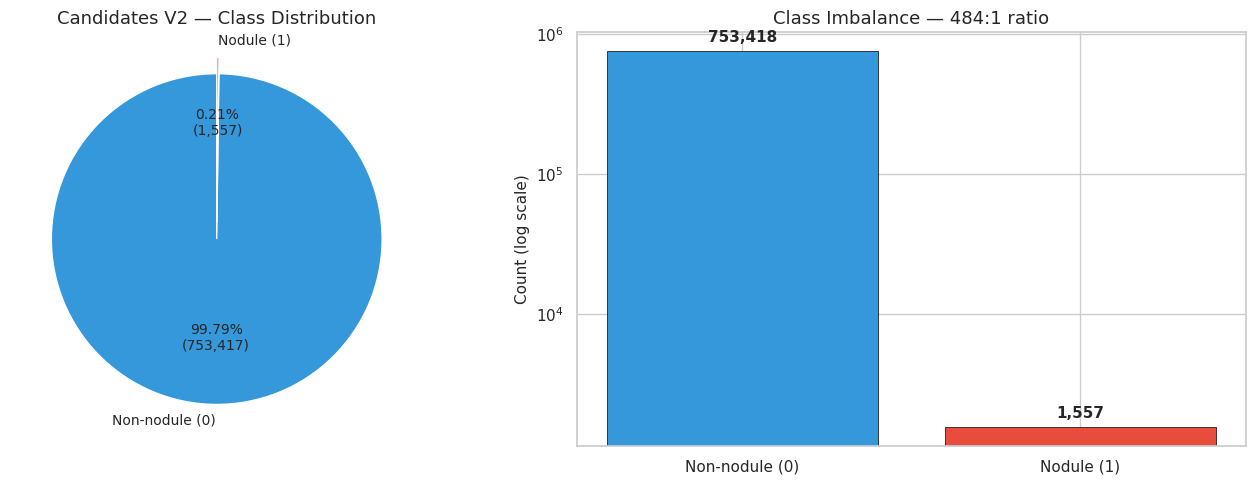

In [142]:
# ── Pie chart + Bar chart ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
labels = ['Non-nodule (0)', 'Nodule (1)']
sizes = [n_neg, n_pos]
colors = ['#3498db', '#e74c3c']
explode = (0, 0.1)
axes[0].pie(sizes, explode=explode, labels=labels, colors=colors,
            autopct=lambda pct: f'{pct:.2f}%\n({int(pct/100*sum(sizes)):,})',
            shadow=False, startangle=90, textprops={'fontsize': 10})
axes[0].set_title('Candidates V2 — Class Distribution', fontsize=13)

# Bar chart (log scale to show both classes)
bars = axes[1].bar(labels, sizes, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_yscale('log')
axes[1].set_ylabel('Count (log scale)', fontsize=11)
axes[1].set_title(f'Class Imbalance — {imbalance_ratio:.0f}:1 ratio', fontsize=13)
for bar, count in zip(bars, sizes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sec2_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Distribución de coordenadas por clase

Histograma de coordenadas X, Y, Z de candidatos para entender la distribución espacial
en el espacio del paciente (coordenadas en mm).

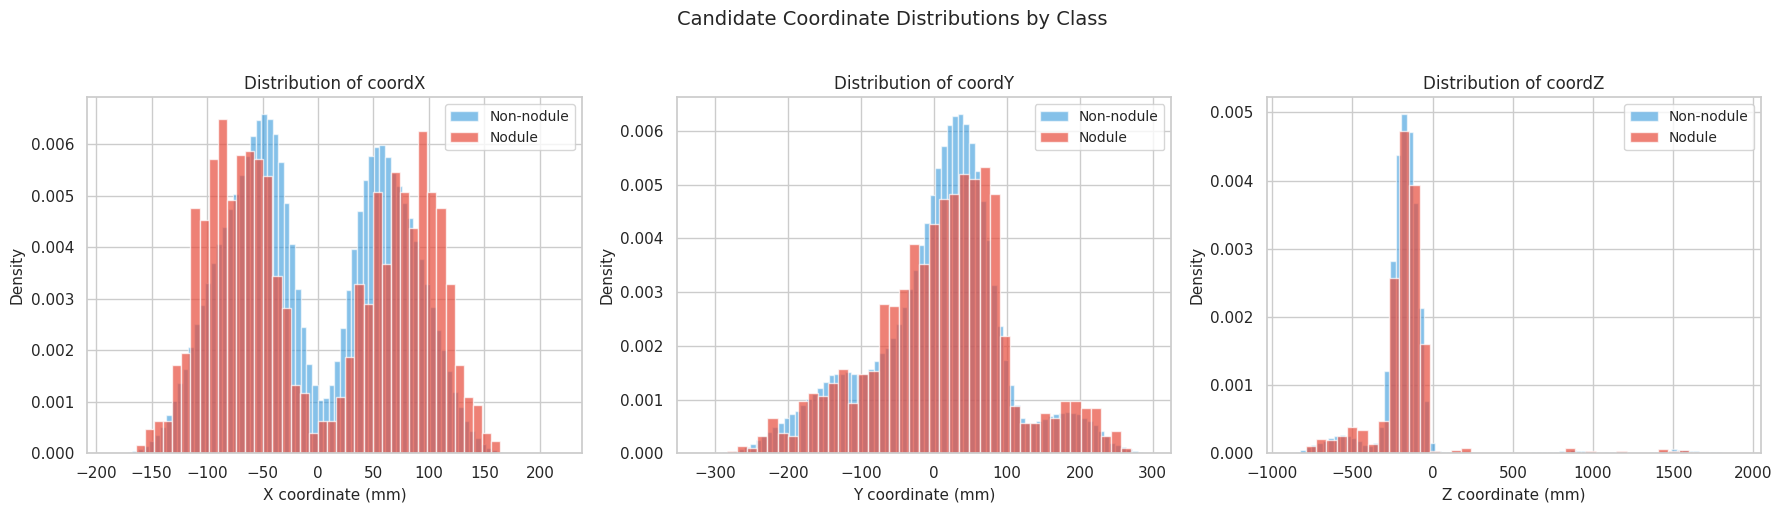

In [143]:
# ── Coordinate distributions split by class ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

coord_cols = ['coordX', 'coordY', 'coordZ']
coord_labels = ['X coordinate (mm)', 'Y coordinate (mm)', 'Z coordinate (mm)']

for ax, col, label in zip(axes, coord_cols, coord_labels):
    # Non-nodules (subsample for performance)
    neg_vals = df_cand.loc[df_cand['class'] == 0, col]
    pos_vals = df_cand.loc[df_cand['class'] == 1, col]

    ax.hist(neg_vals, bins=80, alpha=0.6, label='Non-nodule', color='#3498db', density=True)
    ax.hist(pos_vals, bins=40, alpha=0.7, label='Nodule', color='#e74c3c', density=True)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'Distribution of {col}', fontsize=12)
    ax.legend(fontsize=10)

plt.suptitle('Candidate Coordinate Distributions by Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sec2_coordinate_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Unique series in candidates

In [144]:
# ── Unique series analysis ──────────────────────────────────────
n_series = df_cand['seriesuid'].nunique()
candidates_per_series = df_cand.groupby('seriesuid').size()
pos_per_series = df_cand[df_cand['class'] == 1].groupby('seriesuid').size()

print(f'Unique series in candidates_V2: {n_series}')
print(f'Candidates per series: min={candidates_per_series.min()}, max={candidates_per_series.max()}, '
      f'median={candidates_per_series.median():.0f}, mean={candidates_per_series.mean():.1f}')
print(f'Series with at least 1 nodule: {len(pos_per_series)}')
print(f'Nodules per positive series: min={pos_per_series.min()}, max={pos_per_series.max()}, '
      f'mean={pos_per_series.mean():.2f}')

Unique series in candidates_V2: 888
Candidates per series: min=66, max=2066, median=838, mean=850.2
Series with at least 1 nodule: 600
Nodules per positive series: min=1, max=17, mean=2.60


### Distribución post-submuestreo en disco (estado real de los parches)

El submuestreo de negativos se realizó **por split separado** durante la extracción
de parches (ratio ≈ 10:1 en cada split). Esto es correcto — evita usar el ratio
global que mezclaría muestras entre splits.

In [145]:
# ── Helper local (definido aquí porque esta celda precede a la Sección 5) ──
import re as _re

def get_patch_label(filename, df_candidates):
    """Extrae índice del nombre del archivo y busca la etiqueta en df_candidates."""
    m = _re.match(r'candidate_(\d+)\.npy', filename)
    if m:
        idx = int(m.group(1))
        if idx < len(df_candidates):
            return int(df_candidates.iloc[idx]['class'])
    return None

# ── Distribución real en disco por split (post W-03) ─────────────────
print("Distribución de clases en parches pre-extraídos (post-fix W-03):")
print("=" * 70)
print(f"{'Split':<8} {'Positivos':>10} {'Negativos':>10} {'Total':>10} {'Ratio neg:pos':>15}")
print("-" * 70)

patch_class_stats = {}
for split in ['train', 'val', 'test']:
    split_dir = PATCHES_DIR / split
    if not split_dir.exists():
        print(f"  {split}: directorio no encontrado")
        continue
    pos, neg = 0, 0
    for f in split_dir.glob('*.npy'):
        label = get_patch_label(f.name, df_cand)
        if label == 1:
            pos += 1
        elif label == 0:
            neg += 1
    total = pos + neg
    ratio = neg / pos if pos > 0 else float('inf')
    patch_class_stats[split] = {'pos': pos, 'neg': neg, 'total': total, 'ratio': ratio}
    print(f"{split:<8} {pos:>10,} {neg:>10,} {total:>10,} {ratio:>12.1f}:1")

print("=" * 70)
print()
print("NOTA: El submuestreo se realizó POR SPLIT (no global), lo cual es")
print("      correcto: cada split mantiene su propio ratio ~10:1.")
print("      El split es por 'seriesuid' → sin fuga entre splits.")

Distribución de clases en parches pre-extraídos (post-fix W-03):
Split     Positivos  Negativos      Total   Ratio neg:pos
----------------------------------------------------------------------
train         1,258     13,470     14,728         10.7:1
val             105      1,038      1,143          9.9:1
test            174      1,740      1,914         10.0:1

NOTA: El submuestreo se realizó POR SPLIT (no global), lo cual es
      correcto: cada split mantiene su propio ratio ~10:1.
      El split es por 'seriesuid' → sin fuga entre splits.


---
## Sección 3 — Análisis de Anotaciones

El `annotations.csv` contiene ubicaciones de nódulos con medidas de diámetro.

Columnas: `seriesuid`, `coordX`, `coordY`, `coordZ`, `diameter_mm`.

In [146]:
# ── Load annotations ────────────────────────────────────────────
if ANNOTATIONS_CSV.exists():
    df_ann = pd.read_csv(ANNOTATIONS_CSV)
    print(f'Shape: {df_ann.shape}')
    print(f'\nColumn dtypes:')
    print(df_ann.dtypes)
    print(f'\nFirst 5 rows:')
    display(df_ann.head())
else:
    print(f'WARNING: annotations.csv not found at {ANNOTATIONS_CSV}')
    df_ann = None

Shape: (1186, 5)

Column dtypes:
seriesuid          str
coordX         float64
coordY         float64
coordZ         float64
diameter_mm    float64
dtype: object

First 5 rows:


,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150


### Distribución de tamaños de nódulos (en mm)

Nodule diameter statistics (mm):
  Count:  1186
  Min:    3.25
  Max:    32.27
  Mean:   8.31
  Median: 6.43
  Std:    4.76

  Unique series with annotated nodules: 601


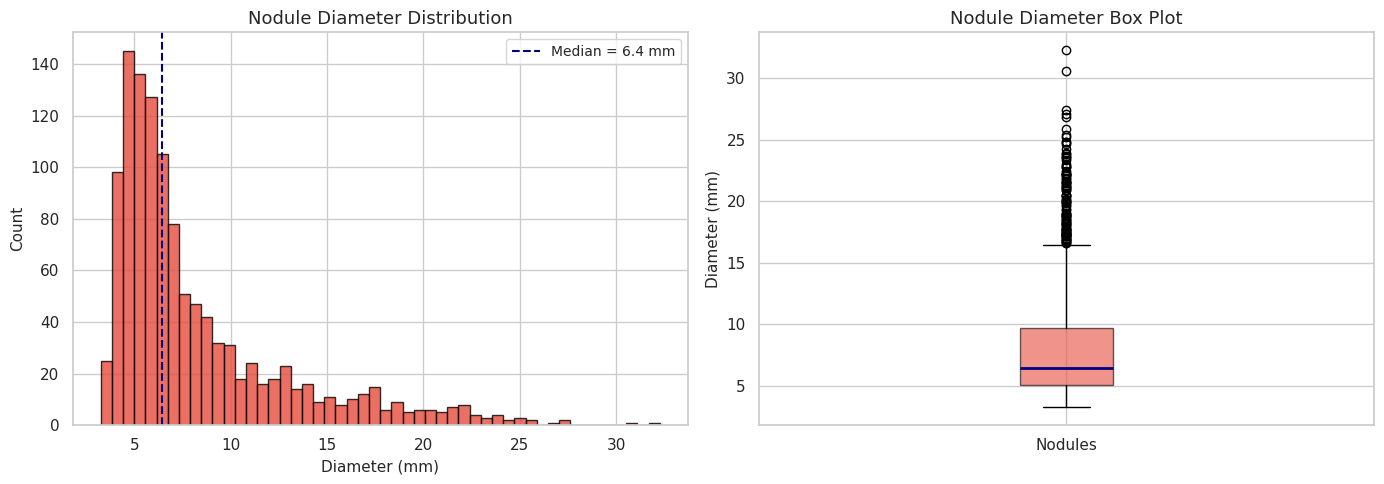

In [147]:
# ── Nodule diameter statistics ────────────────────────────────────
if df_ann is not None:
    diameters = df_ann['diameter_mm']
    print('Nodule diameter statistics (mm):')
    print(f'  Count:  {len(diameters)}')
    print(f'  Min:    {diameters.min():.2f}')
    print(f'  Max:    {diameters.max():.2f}')
    print(f'  Mean:   {diameters.mean():.2f}')
    print(f'  Median: {diameters.median():.2f}')
    print(f'  Std:    {diameters.std():.2f}')
    print()
    print(f'  Unique series with annotated nodules: {df_ann["seriesuid"].nunique()}')

    # Histogram
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(diameters, bins=50, color='#e74c3c', edgecolor='black', alpha=0.8)
    axes[0].axvline(diameters.median(), color='navy', linestyle='--', linewidth=1.5,
                    label=f'Median = {diameters.median():.1f} mm')
    axes[0].set_xlabel('Diameter (mm)', fontsize=11)
    axes[0].set_ylabel('Count', fontsize=11)
    axes[0].set_title('Nodule Diameter Distribution', fontsize=13)
    axes[0].legend(fontsize=10)

    # Box plot
    axes[1].boxplot(diameters, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#e74c3c', alpha=0.6),
                    medianprops=dict(color='navy', linewidth=2))
    axes[1].set_ylabel('Diameter (mm)', fontsize=11)
    axes[1].set_title('Nodule Diameter Box Plot', fontsize=13)
    axes[1].set_xticklabels(['Nodules'])

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'sec3_nodule_diameter.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipped — annotations not loaded.')

### Nódulos por serie CT

Series with annotated nodules: 601
Nodules per series distribution:
count    601.000000
mean       1.973378
std        1.483000
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       12.000000


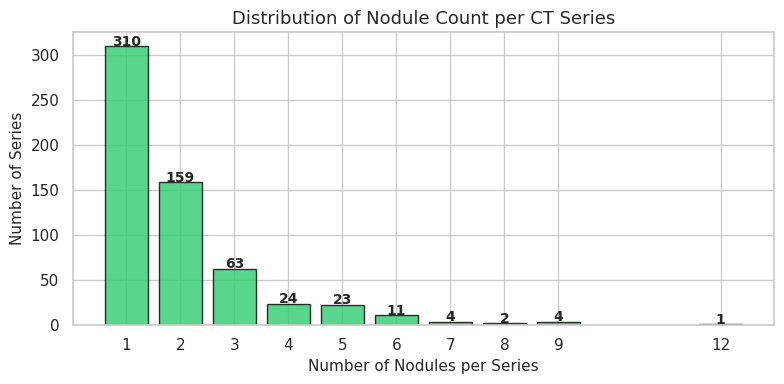

In [148]:
# ── Nodules per series distribution ──────────────────────────────
if df_ann is not None:
    nodules_per_series = df_ann.groupby('seriesuid').size().reset_index(name='nodule_count')
    print(f'Series with annotated nodules: {len(nodules_per_series)}')
    print(f'Nodules per series distribution:')
    print(nodules_per_series['nodule_count'].describe().to_string())

    fig, ax = plt.subplots(figsize=(8, 4))
    counts = nodules_per_series['nodule_count'].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color='#2ecc71', edgecolor='black', alpha=0.8)
    ax.set_xlabel('Number of Nodules per Series', fontsize=11)
    ax.set_ylabel('Number of Series', fontsize=11)
    ax.set_title('Distribution of Nodule Count per CT Series', fontsize=13)
    ax.set_xticks(counts.index)
    for x, y in zip(counts.index, counts.values):
        ax.text(x, y + 0.5, str(y), ha='center', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'sec3_nodules_per_series.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Sección 4 — Inspección de Volúmenes CT

Carga un volumen `.mhd` de ejemplo para inspeccionar espaciado, origen, tamaño y rango HU.
Los volúmenes están en formato MetaImage (`.mhd` encabezado + `.raw` datos).

> **Anatomía:** Las imágenes muestran **tórax humano** con pulmones, costillas y mediastino.
> Los nódulos pulmonares aparecen como densidades redondeadas en el parénquima pulmonar.

In [149]:
# ── Load a sample CT volume ─────────────────────────────────────
if HAS_SITK:
    # Find first available .mhd file
    sample_mhd = None
    for i in range(10):
        subset_dir = CT_VOLUMES_DIR / f'subset{i}'
        if subset_dir.exists():
            mhd_files = sorted(subset_dir.glob('*.mhd'))
            if mhd_files:
                sample_mhd = mhd_files[0]
                break

    if sample_mhd:
        print(f'Loading: {sample_mhd.name}')
        print(f'  From: subset{i}')
        print()

        img = sitk.ReadImage(str(sample_mhd))
        arr = sitk.GetArrayFromImage(img)  # shape: (Z, Y, X)

        print(f'Volume properties:')
        print(f'  Size (x,y,z):    {img.GetSize()}')
        print(f'  Spacing (mm):    {tuple(round(s,4) for s in img.GetSpacing())}')
        print(f'  Origin (mm):     {tuple(round(o,2) for o in img.GetOrigin())}')
        print(f'  Pixel type:      {img.GetPixelIDTypeAsString()}')
        print(f'  Array shape:     {arr.shape}  (Z, Y, X)')
        print(f'  Array dtype:     {arr.dtype}')
        print(f'  HU range:        [{arr.min()}, {arr.max()}]')
        print(f'  HU mean:         {arr.mean():.2f}')
    else:
        print('No .mhd files found in any subset directory.')
        arr = None
        img = None
else:
    print('SimpleITK not available — skipping CT volume inspection.')
    arr = None
    img = None

Loading: 1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260.mhd
  From: subset0

Volume properties:
  Size (x,y,z):    (512, 512, 121)
  Spacing (mm):    (0.7617, 0.7617, 2.5)
  Origin (mm):     (-198.1, -195.0, -335.21)
  Pixel type:      16-bit signed integer
  Array shape:     (121, 512, 512)  (Z, Y, X)
  Array dtype:     int16
  HU range:        [-3024, 2103]
  HU mean:         -1035.62


### Visualización de slices centrales (axial, coronal, sagital)

Los tres planos anatómicos permiten verificar la integridad del volumen CT de tórax.

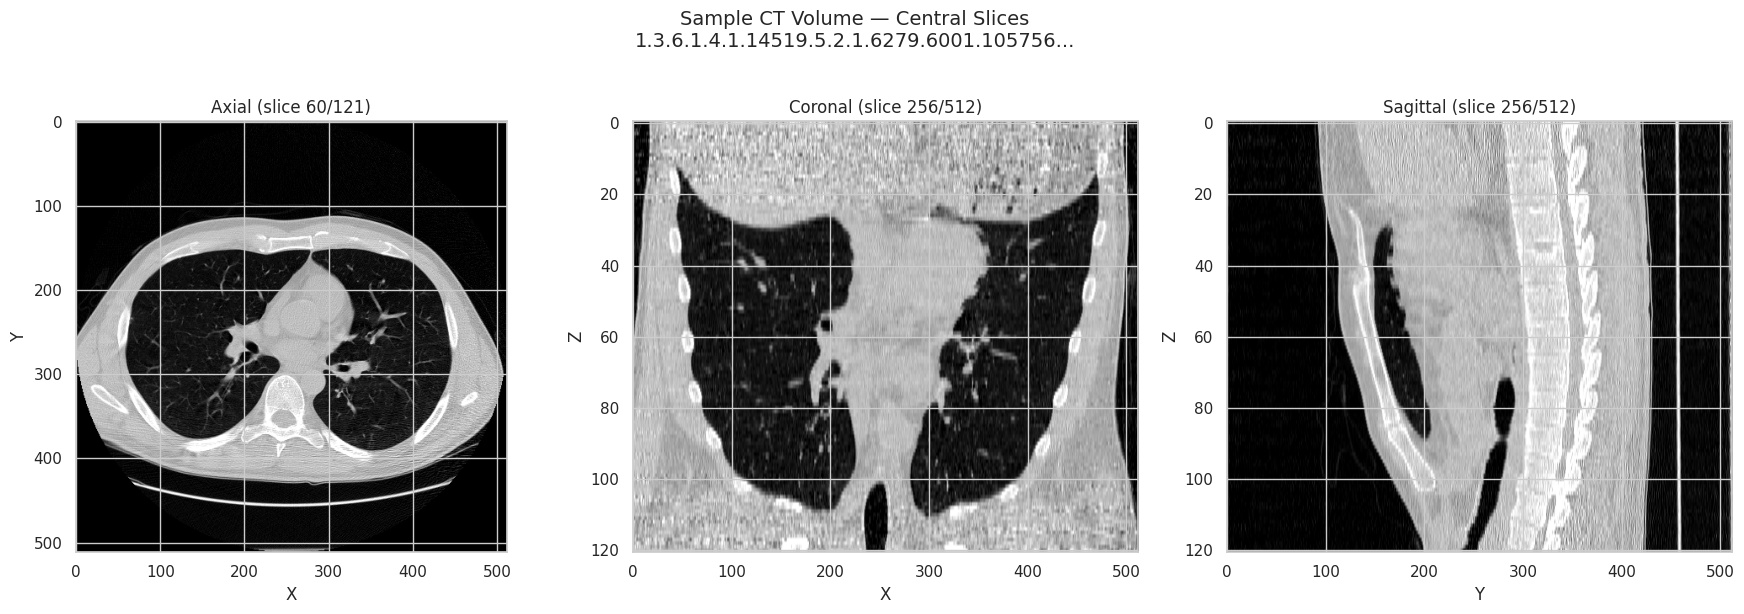

In [150]:
# ── Visualize central slices ────────────────────────────────────
if arr is not None:
    z_mid = arr.shape[0] // 2
    y_mid = arr.shape[1] // 2
    x_mid = arr.shape[2] // 2

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Axial slice (Z fixed)
    axes[0].imshow(arr[z_mid, :, :], cmap='gray', vmin=-1000, vmax=400)
    axes[0].set_title(f'Axial (slice {z_mid}/{arr.shape[0]})', fontsize=12)
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')

    # Coronal slice (Y fixed)
    axes[1].imshow(arr[:, y_mid, :], cmap='gray', vmin=-1000, vmax=400, aspect='auto')
    axes[1].set_title(f'Coronal (slice {y_mid}/{arr.shape[1]})', fontsize=12)
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Z')

    # Sagittal slice (X fixed)
    axes[2].imshow(arr[:, :, x_mid], cmap='gray', vmin=-1000, vmax=400, aspect='auto')
    axes[2].set_title(f'Sagittal (slice {x_mid}/{arr.shape[2]})', fontsize=12)
    axes[2].set_xlabel('Y')
    axes[2].set_ylabel('Z')

    plt.suptitle(f'Sample CT Volume — Central Slices\n{sample_mhd.stem[:40]}...',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'sec4_ct_central_slices.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipped — no volume loaded.')

### Variabilidad de espaciado entre volúmenes

El espaciado voxel es importante porque el modelo espera tamaños de voxel consistentes.
Se muestrea un subconjunto de volúmenes de diferentes subsets para verificar.

In [151]:
# ── Spacing variability survey ──────────────────────────────────
if HAS_SITK:
    spacings = []
    sizes = []
    for i in range(10):
        subset_dir = CT_VOLUMES_DIR / f'subset{i}'
        if not subset_dir.exists():
            continue
        mhd_files = sorted(subset_dir.glob('*.mhd'))
        # Sample first 3 per subset for speed
        for mhd_path in mhd_files[:3]:
            try:
                reader = sitk.ImageFileReader()
                reader.SetFileName(str(mhd_path))
                reader.ReadImageInformation()
                spacings.append(reader.GetSpacing())
                sizes.append(reader.GetSize())
            except Exception:
                pass

    if spacings:
        sp_arr = np.array(spacings)
        sz_arr = np.array(sizes)
        print(f'Surveyed {len(spacings)} volumes across subsets:')
        print(f'  Spacing X:  min={sp_arr[:,0].min():.4f}, max={sp_arr[:,0].max():.4f}, mean={sp_arr[:,0].mean():.4f} mm')
        print(f'  Spacing Y:  min={sp_arr[:,1].min():.4f}, max={sp_arr[:,1].max():.4f}, mean={sp_arr[:,1].mean():.4f} mm')
        print(f'  Spacing Z:  min={sp_arr[:,2].min():.4f}, max={sp_arr[:,2].max():.4f}, mean={sp_arr[:,2].mean():.4f} mm')
        print(f'  Size X:     min={sz_arr[:,0].min()}, max={sz_arr[:,0].max()}')
        print(f'  Size Y:     min={sz_arr[:,1].min()}, max={sz_arr[:,1].max()}')
        print(f'  Size Z:     min={sz_arr[:,2].min()}, max={sz_arr[:,2].max()}')
        print()
        print('  NOTE: Significant Z-spacing variability is expected in CT data.')
        print('  Patches are extracted at fixed voxel resolution, so this is handled.')
else:
    print('SimpleITK not available — skipping spacing survey.')

Surveyed 30 volumes across subsets:
  Spacing X:  min=0.4883, max=0.8789, mean=0.7034 mm
  Spacing Y:  min=0.4883, max=0.8789, mean=0.7034 mm
  Spacing Z:  min=0.6250, max=2.5000, mean=1.5825 mm
  Size X:     min=512, max=512
  Size Y:     min=512, max=512
  Size Z:     min=117, max=481

  NOTE: Significant Z-spacing variability is expected in CT data.
  Patches are extracted at fixed voxel resolution, so this is handled.


---
## Sección 5 — Análisis de Parches

Examina los parches `.npy` pre-extraídos para verificar forma, rango de valores y contenido visual.

Los parches se nombran `candidate_NNNNNN.npy` donde `NNNNNN` es el índice 0-based en `candidates_V2.csv`.
Esto permite recuperar la etiqueta de clase para cualquier parche.

In [152]:
# ── Helper: get label for a patch filename ──────────────────────
def get_patch_label(filename, df_candidates):
    """Extract candidate index from filename and look up class label."""
    m = re.match(r'candidate_(\d+)\.npy', filename)
    if m:
        idx = int(m.group(1))
        if idx < len(df_candidates):
            return df_candidates.iloc[idx]['class']
    return None

# ── Find positive and negative samples ────────────────────────────
train_dir = PATCHES_DIR / 'train'
pos_examples = []
neg_examples = []

if train_dir.exists() and 'df_cand' in dir():
    for f in sorted(train_dir.glob('*.npy')):
        label = get_patch_label(f.name, df_cand)
        if label == 1 and len(pos_examples) < 3:
            pos_examples.append(f)
        elif label == 0 and len(neg_examples) < 3:
            neg_examples.append(f)
        if len(pos_examples) >= 3 and len(neg_examples) >= 3:
            break

print(f'Found {len(pos_examples)} positive and {len(neg_examples)} negative sample patches.')
for p in pos_examples:
    print(f'  [POS] {p.name}')
for p in neg_examples:
    print(f'  [NEG] {p.name}')

Found 3 positive and 3 negative sample patches.
  [POS] candidate_000436.npy
  [POS] candidate_001009.npy
  [POS] candidate_003633.npy
  [NEG] candidate_000080.npy
  [NEG] candidate_000261.npy
  [NEG] candidate_000285.npy


### Verificación de forma y rango de valores de parches

In [153]:
# ── Load and inspect sample patches ──────────────────────────────
all_samples = pos_examples + neg_examples
sample_labels = ['NODULE'] * len(pos_examples) + ['NON-NODULE'] * len(neg_examples)

print('Patch inspection:')
print('-' * 70)
print(f'{"File":<30} {"Shape":<18} {"Dtype":<10} {"Min":>6} {"Max":>6} {"Mean":>8}')
print('-' * 70)
for f, lbl in zip(all_samples, sample_labels):
    patch = np.load(f)
    print(f'{f.name:<30} {str(patch.shape):<18} {str(patch.dtype):<10} '
          f'{patch.min():>6.3f} {patch.max():>6.3f} {patch.mean():>8.4f}  [{lbl}]')

print()
print('Expected: shape=(64,64,64), dtype=float32, range=[0,1] (after HU clip + rescale)')

Patch inspection:
----------------------------------------------------------------------
File                           Shape              Dtype         Min    Max     Mean
----------------------------------------------------------------------
candidate_000436.npy           (64, 64, 64)       float32     0.000  1.000   0.1779  [NODULE]
candidate_001009.npy           (64, 64, 64)       float32     0.000  1.000   0.4515  [NODULE]
candidate_003633.npy           (64, 64, 64)       float32     0.000  1.000   0.2417  [NODULE]
candidate_000080.npy           (64, 64, 64)       float32     0.000  1.000   0.0903  [NON-NODULE]
candidate_000261.npy           (64, 64, 64)       float32     0.000  1.000   0.5028  [NON-NODULE]
candidate_000285.npy           (64, 64, 64)       float32     0.000  1.000   0.4434  [NON-NODULE]

Expected: shape=(64,64,64), dtype=float32, range=[0,1] (after HU clip + rescale)


### Comparación visual: parche con nódulo vs sin nódulo

Slices centrales (axial, coronal, sagital) de un ejemplo positivo y negativo.

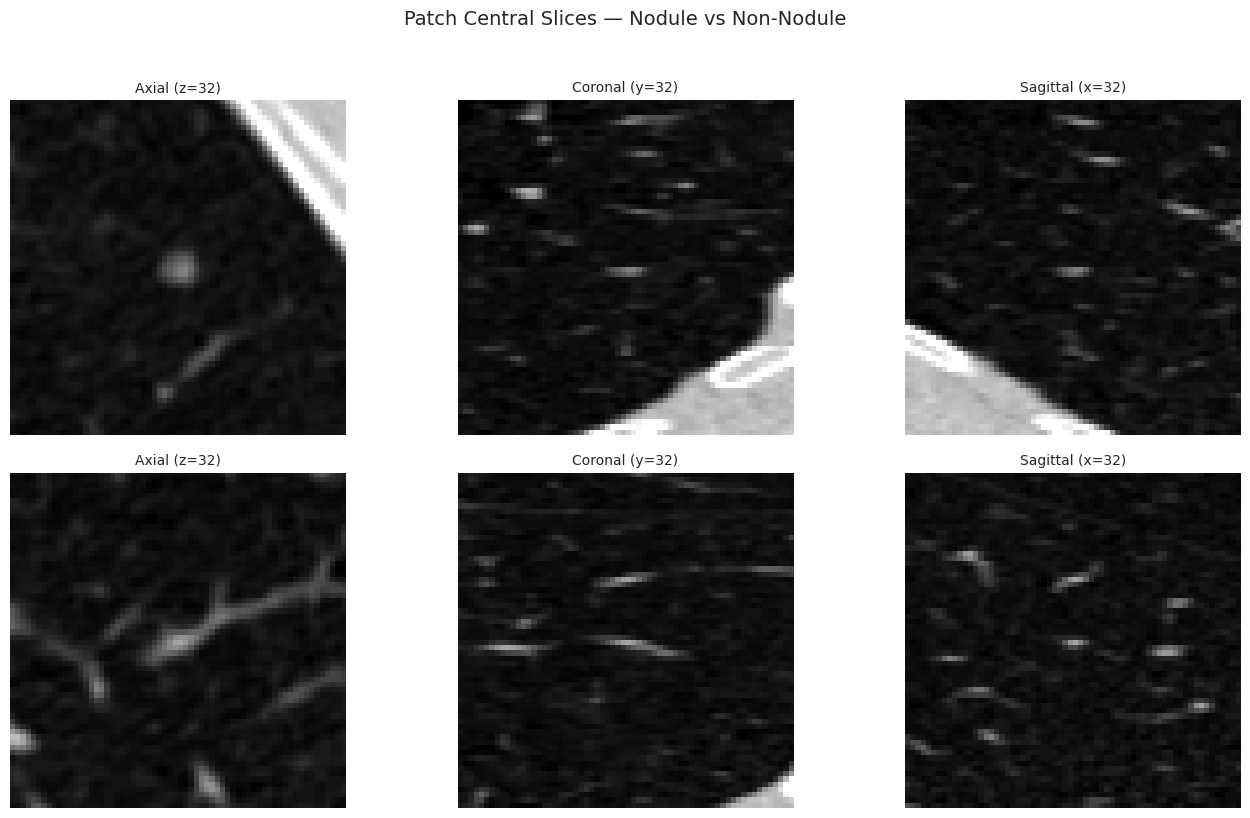

In [154]:
# ── Visualize positive vs negative patches ────────────────────────
def plot_patch_slices(patch, title, axes_row):
    """Plot axial, coronal, sagittal central slices of a 3D patch."""
    z, y, x = patch.shape[0]//2, patch.shape[1]//2, patch.shape[2]//2
    slices = [
        (patch[z, :, :], f'Axial (z={z})'),
        (patch[:, y, :], f'Coronal (y={y})'),
        (patch[:, :, x], f'Sagittal (x={x})'),
    ]
    for ax, (sl, sl_title) in zip(axes_row, slices):
        ax.imshow(sl, cmap='gray', vmin=0, vmax=1)
        ax.set_title(sl_title, fontsize=10)
        ax.axis('off')
    axes_row[0].set_ylabel(title, fontsize=12, fontweight='bold', rotation=0,
                           labelpad=80, va='center')

if len(pos_examples) > 0 and len(neg_examples) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))

    pos_patch = np.load(pos_examples[0])
    neg_patch = np.load(neg_examples[0])

    plot_patch_slices(pos_patch, 'NODULE', axes[0])
    plot_patch_slices(neg_patch, 'NON-NODULE', axes[1])

    plt.suptitle('Patch Central Slices — Nodule vs Non-Nodule', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'sec5_patch_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Could not find both positive and negative examples.')

### Galería de ejemplos positivos (nódulos confirmados)

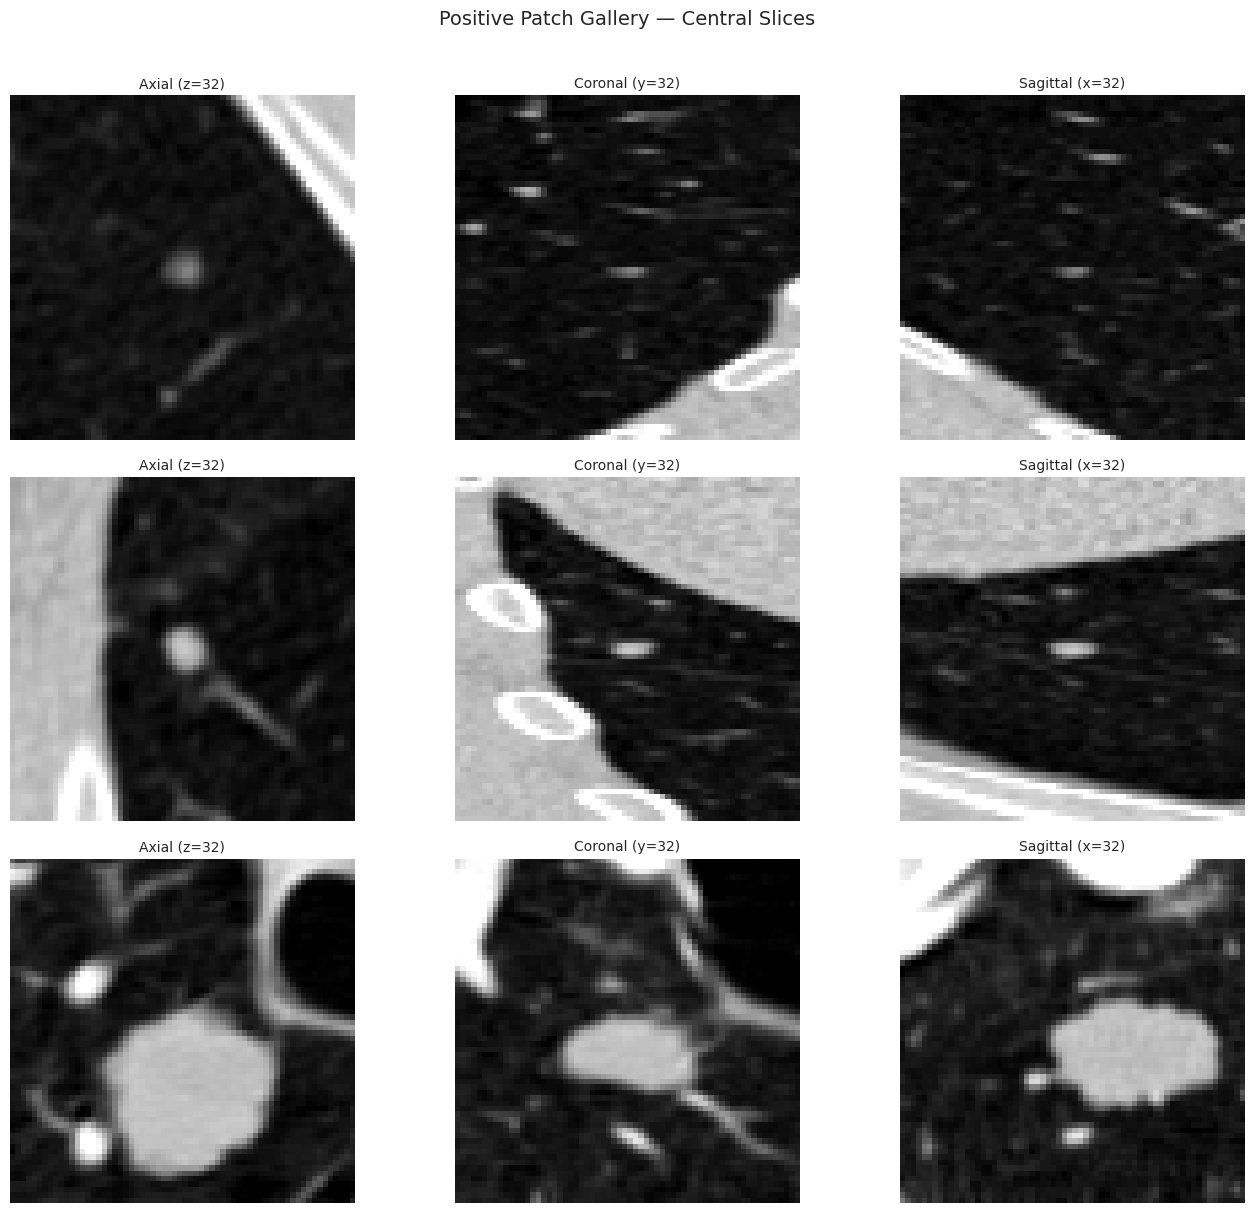

In [155]:
# ── Show multiple positive patches for diversity ─────────────────
if len(pos_examples) >= 2:
    fig, axes = plt.subplots(len(pos_examples), 3, figsize=(14, 4 * len(pos_examples)))
    if len(pos_examples) == 1:
        axes = [axes]

    for i, pf in enumerate(pos_examples):
        patch = np.load(pf)
        plot_patch_slices(patch, pf.name.replace('.npy',''), axes[i])

    plt.suptitle('Positive Patch Gallery — Central Slices', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'sec5_positive_gallery.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Not enough positive examples for gallery.')

---
## Sección 6 — Análisis Profundo del Desbalance de Clases

El dataset LUNA16 tiene desbalance extremo. Lo analizamos en dos niveles:
1. **CSV candidates_V2 completo** (~484:1 ratio — datos brutos sin procesar)
2. **Parches pre-extraídos** (submuestreados a ~10:1 por split)

In [156]:
# ── Per-split class distribution (patches) ─────────────────────
split_stats = {}
for split in ['train', 'val', 'test']:
    split_dir = PATCHES_DIR / split
    if not split_dir.exists():
        continue
    pos = 0
    neg = 0
    for f in split_dir.glob('*.npy'):
        label = get_patch_label(f.name, df_cand)
        if label == 1:
            pos += 1
        elif label == 0:
            neg += 1
    total = pos + neg
    ratio = neg / pos if pos > 0 else float('inf')
    split_stats[split] = {'pos': pos, 'neg': neg, 'total': total, 'ratio': ratio}

print('Per-split class distribution (pre-extracted patches):')
print('=' * 65)
print(f'{"Split":<8} {"Positive":>10} {"Negative":>10} {"Total":>10} {"Ratio (neg:pos)":>16}')
print('-' * 65)
for split, stats in split_stats.items():
    print(f'{split:<8} {stats["pos"]:>10,} {stats["neg"]:>10,} {stats["total"]:>10,} {stats["ratio"]:>13.1f}:1')
print('=' * 65)

Per-split class distribution (pre-extracted patches):
Split      Positive   Negative      Total  Ratio (neg:pos)
-----------------------------------------------------------------
train         1,258     13,470     14,728          10.7:1
val             105      1,038      1,143           9.9:1
test            174      1,740      1,914          10.0:1


### Visualización del desbalance por split

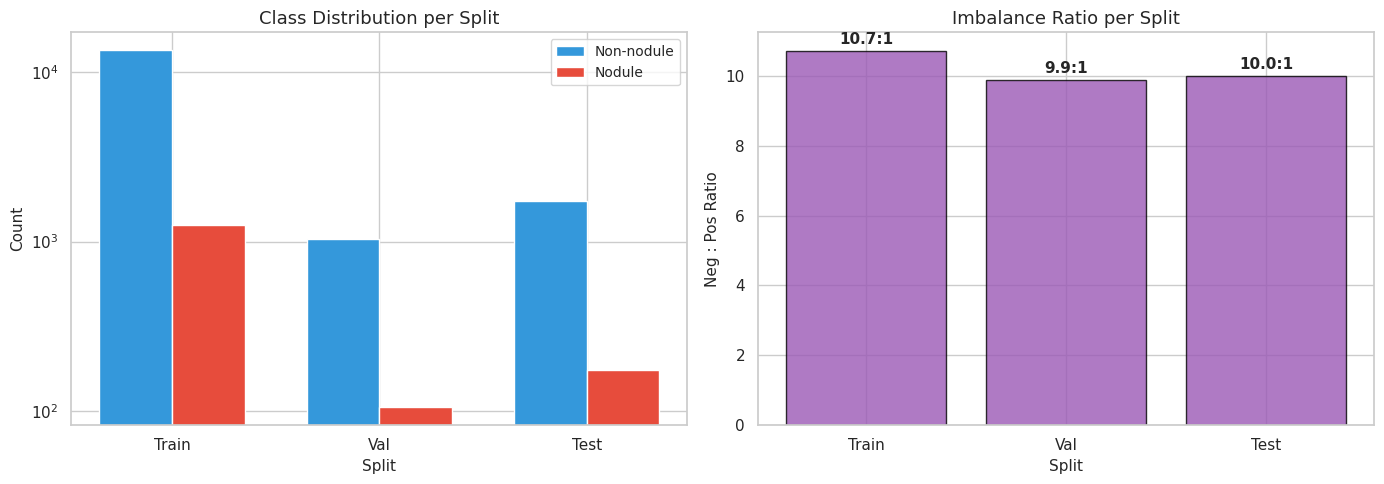

In [157]:
# ── Stacked bar chart of class distribution per split ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute counts
splits = list(split_stats.keys())
pos_counts = [split_stats[s]['pos'] for s in splits]
neg_counts = [split_stats[s]['neg'] for s in splits]

x = np.arange(len(splits))
width = 0.35
bars1 = axes[0].bar(x - width/2, neg_counts, width, label='Non-nodule', color='#3498db')
bars2 = axes[0].bar(x + width/2, pos_counts, width, label='Nodule', color='#e74c3c')
axes[0].set_xlabel('Split', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Class Distribution per Split', fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels([s.capitalize() for s in splits])
axes[0].legend(fontsize=10)
axes[0].set_yscale('log')

# Right: imbalance ratios
ratios = [split_stats[s]['ratio'] for s in splits]
bars = axes[1].bar(splits, ratios, color='#9b59b6', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Split', fontsize=11)
axes[1].set_ylabel('Neg : Pos Ratio', fontsize=11)
axes[1].set_title('Imbalance Ratio per Split', fontsize=13)
axes[1].set_xticklabels([s.capitalize() for s in splits])
for bar, r in zip(bars, ratios):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{r:.1f}:1', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sec6_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

### Por qué FocalLoss es obligatoria — y corrección de alpha

Con ratio ~484:1 en los datos brutos y ~10:1 en los parches extraídos:

- La **cross-entropy estándar** sería dominada por los negativos fáciles
- **FocalLoss(γ=2, α=0.85)** soluciona ambos problemas:
  - `γ=2`: reduce fuertemente la loss para ejemplos bien clasificados (Lin et al. 2017)
  - `α=0.85`: ⚠️ **CORRECCIÓN respecto al EDA original** — alpha fue ajustado de 0.25 a **0.85**

#### Justificación del ajuste de alpha:
```
n_neg / n_total = 13.470 / 14.728 ≈ 0.915
→ El peso correcto para la clase POSITIVA (minoritaria) debe ser ALTO (~0.85)
→ alpha=0.25 estaba invirtiendo la ponderación (sub-pesando los nódulos)
→ Ver src/pipeline/fase2/expert3_config.py: EXPERT3_FOCAL_ALPHA = 0.85
```

---
## Sección 7 — Validación del Pipeline de Preprocesado

### Pipeline modo "embedding" (Fase 1) — 2D para backbone compartido

Demuestra el pipeline completo de la capa DataLoader en **modo embedding**:

1. Carga parche `.npy` → `(64, 64, 64)`
2. Extrae 3 slices centrales (índice=32): axial, coronal, sagital
3. Apila como pseudo-RGB → `[3, 64, 64]`
4. Interpolación bilineal → `[3, 224, 224]`
5. Normalización ImageNet → tensor final

> **Nota:** Este pipeline es CORRECTO y es el diseño documentado para Fase 1
> (extracción de embeddings para el router MoE). NO es el pipeline del Expert 3.

In [158]:
# ── Step-by-step pipeline demonstration ─────────────────────────
if len(pos_examples) > 0:
    sample_path = pos_examples[0]
    print(f'Pipeline demonstration using: {sample_path.name}')
    print('=' * 60)

    # Step 1: Load .npy
    volume = np.load(sample_path)
    print(f'\n[Step 1] Load .npy patch:')
    print(f'  Shape: {volume.shape}')
    print(f'  Dtype: {volume.dtype}')
    print(f'  Range: [{volume.min():.4f}, {volume.max():.4f}]')
    print(f'  Mean:  {volume.mean():.4f}')

    # Step 2: Extract 3 central slices
    mid = volume.shape[0] // 2  # = 32 for 64^3
    axial   = volume[mid, :, :]      # (64, 64)
    coronal = volume[:, mid, :]      # (64, 64)
    sagittal = volume[:, :, mid]     # (64, 64)
    print(f'\n[Step 2] Extract central slices (index={mid}):')
    print(f'  Axial:    {axial.shape}, range=[{axial.min():.4f}, {axial.max():.4f}]')
    print(f'  Coronal:  {coronal.shape}, range=[{coronal.min():.4f}, {coronal.max():.4f}]')
    print(f'  Sagittal: {sagittal.shape}, range=[{sagittal.min():.4f}, {sagittal.max():.4f}]')

    # Step 3: Stack as pseudo-RGB
    pseudo_rgb = np.stack([axial, coronal, sagittal], axis=0)  # (3, 64, 64)
    print(f'\n[Step 3] Stack as pseudo-RGB:')
    print(f'  Shape: {pseudo_rgb.shape}')
    print(f'  Range: [{pseudo_rgb.min():.4f}, {pseudo_rgb.max():.4f}]')

    # Step 4: Bilinear interpolation to 224x224
    if HAS_TORCH:
        tensor = torch.from_numpy(pseudo_rgb).unsqueeze(0).float()  # (1, 3, 64, 64)
        resized = F.interpolate(tensor, size=(224, 224), mode='bilinear', align_corners=False)
        resized = resized.squeeze(0)  # (3, 224, 224)
        print(f'\n[Step 4] Bilinear interpolation (torch):')
        print(f'  Shape: {tuple(resized.shape)}')
        print(f'  Range: [{resized.min().item():.4f}, {resized.max().item():.4f}]')
    else:
        from scipy.ndimage import zoom
        scale = 224 / 64
        resized_np = np.stack([zoom(pseudo_rgb[c], scale, order=1) for c in range(3)])
        resized = resized_np
        print(f'\n[Step 4] Bilinear interpolation (scipy):')
        print(f'  Shape: {resized.shape}')
        print(f'  Range: [{resized.min():.4f}, {resized.max():.4f}]')

    # Step 5: ImageNet normalization
    imagenet_mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    imagenet_std  = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)

    if HAS_TORCH:
        resized_np = resized.numpy()
    else:
        resized_np = resized

    normalized = (resized_np - imagenet_mean) / imagenet_std
    print(f'\n[Step 5] ImageNet normalization:')
    print(f'  Shape: {normalized.shape}')
    print(f'  Range: [{normalized.min():.4f}, {normalized.max():.4f}]')
    print(f'  Mean per channel: {[f"{normalized[c].mean():.4f}" for c in range(3)]}')
    print(f'  Std per channel:  {[f"{normalized[c].std():.4f}" for c in range(3)]}')

    print(f'\n  Final tensor shape: {normalized.shape}  (matches [3, 224, 224] expectation)')
else:
    print('No positive examples available for pipeline demonstration.')

Pipeline demonstration using: candidate_000436.npy

[Step 1] Load .npy patch:
  Shape: (64, 64, 64)
  Dtype: float32
  Range: [0.0000, 1.0000]
  Mean:  0.1779

[Step 2] Extract central slices (index=32):
  Axial:    (64, 64), range=[0.0114, 1.0000]
  Coronal:  (64, 64), range=[0.0000, 1.0000]
  Sagittal: (64, 64), range=[0.0000, 1.0000]

[Step 3] Stack as pseudo-RGB:
  Shape: (3, 64, 64)
  Range: [0.0000, 1.0000]

[Step 4] Bilinear interpolation (torch):
  Shape: (3, 224, 224)
  Range: [0.0000, 1.0000]

[Step 5] ImageNet normalization:
  Shape: (3, 224, 224)
  Range: [-2.0584, 2.6400]
  Mean per channel: ['-1.4972', '-1.3498', '-1.1450']
  Std per channel:  ['0.9614', '1.0269', '0.9987']

  Final tensor shape: (3, 224, 224)  (matches [3, 224, 224] expectation)


### Visualización paso a paso del pipeline de embedding (modo 2D)

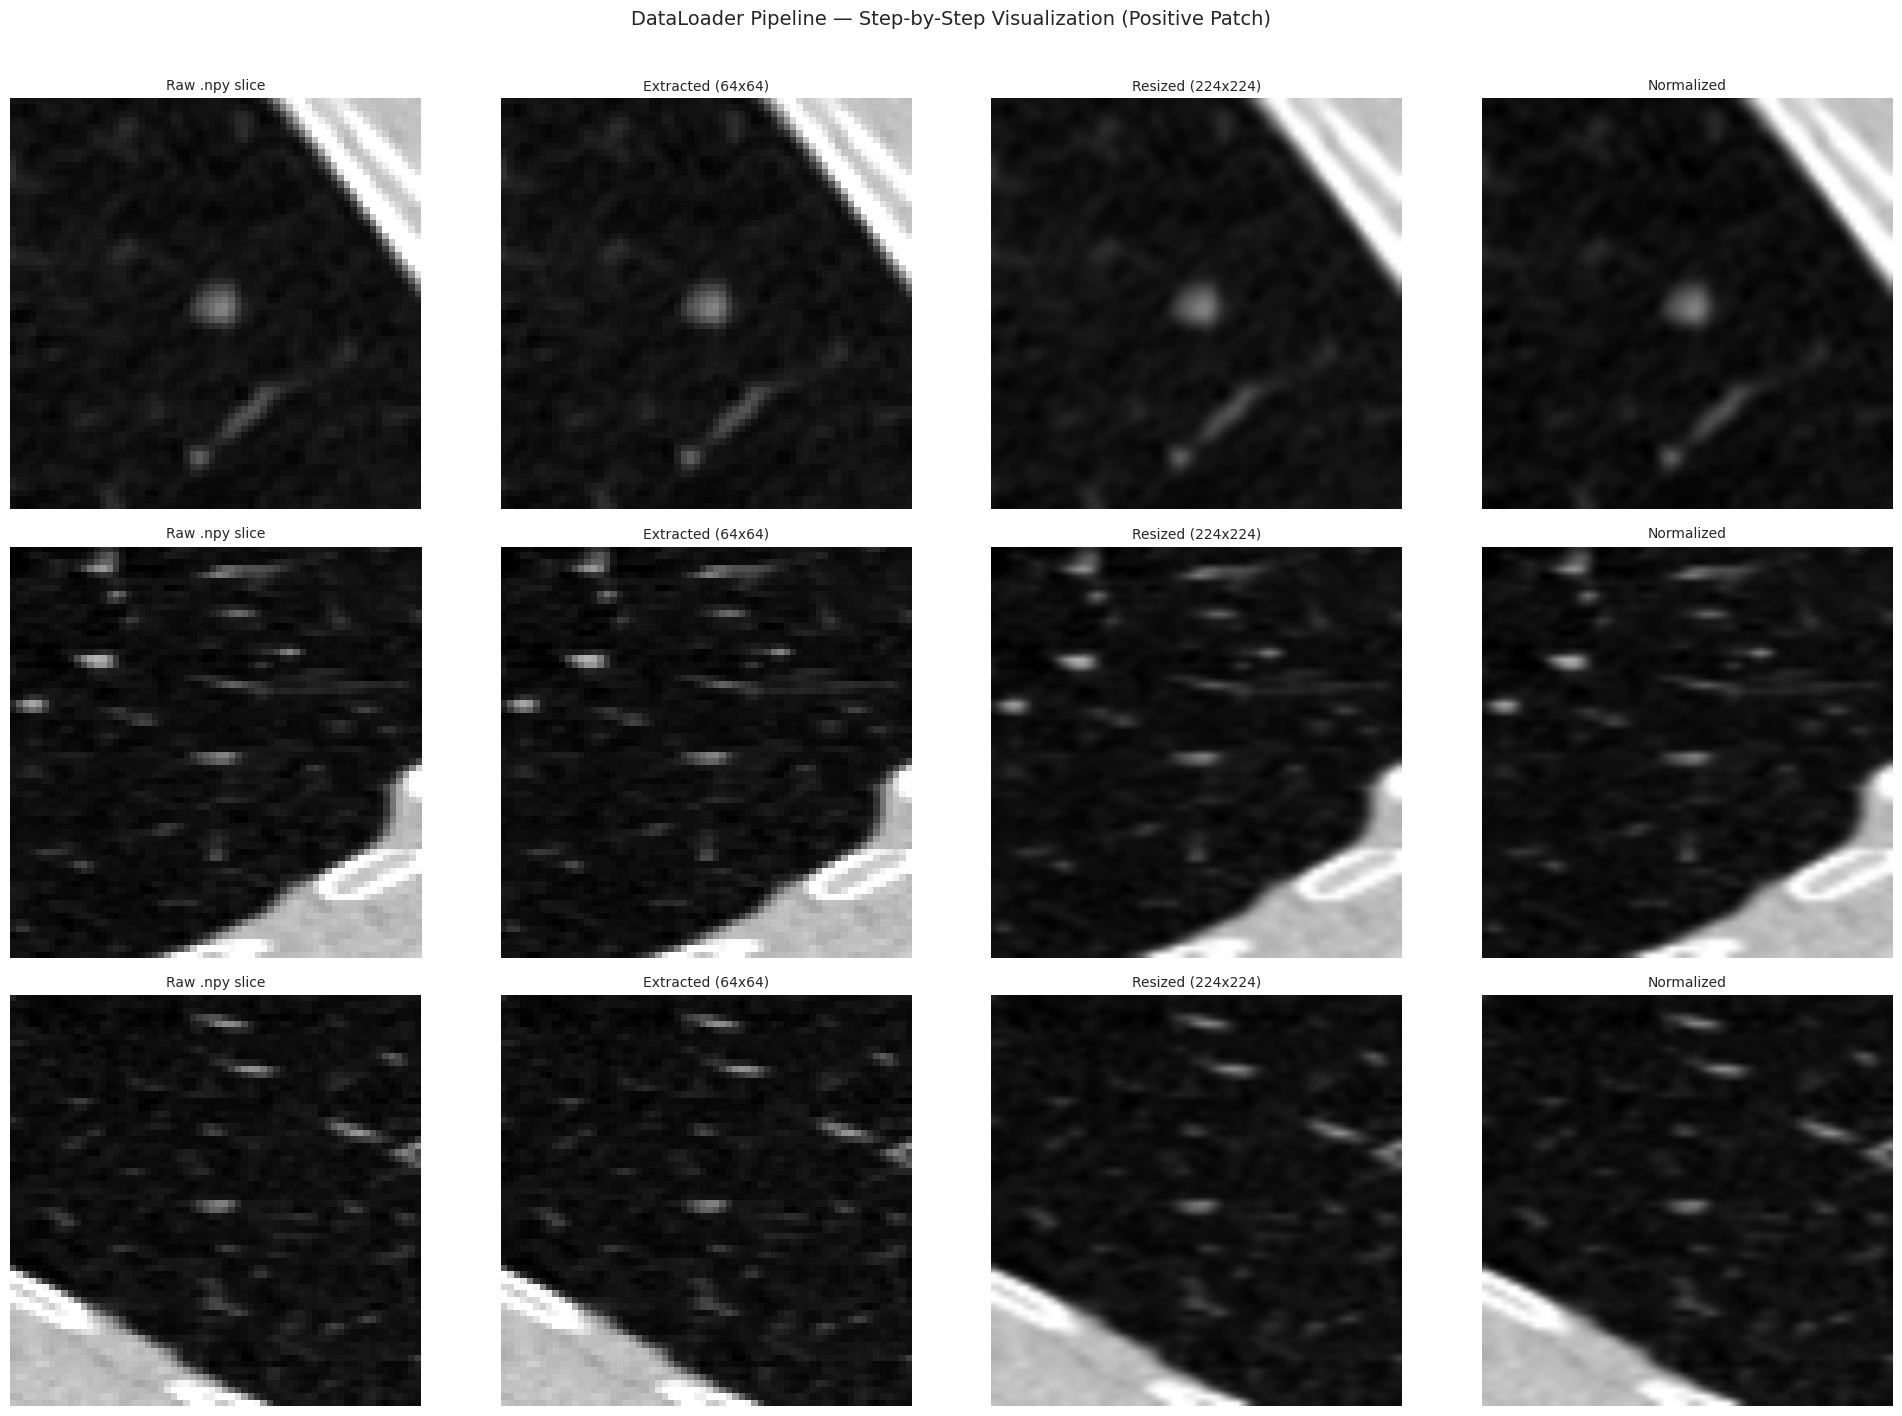

In [159]:
# ── Visualize each pipeline step ────────────────────────────────
if len(pos_examples) > 0:
    fig, axes = plt.subplots(3, 4, figsize=(20, 14))

    channel_names = ['Axial', 'Coronal', 'Sagittal']
    step_names = ['Raw .npy slice', 'Extracted (64x64)', 'Resized (224x224)', 'Normalized']

    # Prepare data for each step
    volume = np.load(pos_examples[0])
    mid = volume.shape[0] // 2
    slices_64 = [volume[mid, :, :], volume[:, mid, :], volume[:, :, mid]]

    if HAS_TORCH:
        pseudo = torch.from_numpy(np.stack(slices_64)).unsqueeze(0).float()
        slices_224 = F.interpolate(pseudo, size=(224, 224), mode='bilinear',
                                   align_corners=False).squeeze(0).numpy()
    else:
        from scipy.ndimage import zoom
        scale = 224 / 64
        slices_224 = np.stack([zoom(s, scale, order=1) for s in slices_64])

    slices_norm = (slices_224 - imagenet_mean) / imagenet_std

    for row, ch_name in enumerate(channel_names):
        # Col 0: Raw 3D slice in volume context
        axes[row, 0].imshow(slices_64[row], cmap='gray', vmin=0, vmax=1)
        axes[row, 0].set_title(f'{step_names[0]}', fontsize=10)
        axes[row, 0].set_ylabel(ch_name, fontsize=12, fontweight='bold')

        # Col 1: Extracted 64x64
        axes[row, 1].imshow(slices_64[row], cmap='gray', vmin=0, vmax=1)
        axes[row, 1].set_title(f'{step_names[1]}', fontsize=10)

        # Col 2: Resized 224x224
        axes[row, 2].imshow(slices_224[row], cmap='gray', vmin=0, vmax=1)
        axes[row, 2].set_title(f'{step_names[2]}', fontsize=10)

        # Col 3: Normalized (rescale for display)
        disp = slices_norm[row]
        axes[row, 3].imshow(disp, cmap='gray')
        axes[row, 3].set_title(f'{step_names[3]}', fontsize=10)

    for ax in axes.ravel():
        ax.axis('off')

    plt.suptitle('DataLoader Pipeline — Step-by-Step Visualization (Positive Patch)',
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'sec7_pipeline_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipped — no positive examples found.')

### Pipeline modo "expert" (Fase 2) — volumen 3D para MC3-18

El Expert 3 recibe el **volumen completo 3D** sin ningún upscaling:

1. Carga parche `.npy` → `(64, 64, 64)` float32, rango [0,1]
2. **Sin resize** — MC3-18 espera exactamente `[1, 64, 64, 64]` (canal único)
3. Sin normalización ImageNet (no aplica a datos médicos 3D monocanal)

> **Diferencia clave con modo embedding:**
> - `mode="embedding"` → 3 slices 2D, resize 224×224, normalización ImageNet → backbone 2D
> - `mode="expert"` → volumen 3D completo, sin resize, sin normalización adicional → MC3-18
>
> Ambos modos son CORRECTOS para sus respectivas fases.

Pipeline modo 'expert' — volumen 3D para MC3-18:
  Shape entrada (.npy):  (64, 64, 64)  → dtype: float32
  Rango de valores:      [0.0000, 1.0000]
  Shape para MC3-18:     (1, 64, 64, 64)  [canal, D, H, W]
  Sin resize — MC3-18 acepta volúmenes 64³
  Sin normalización ImageNet (datos médicos monocanal)



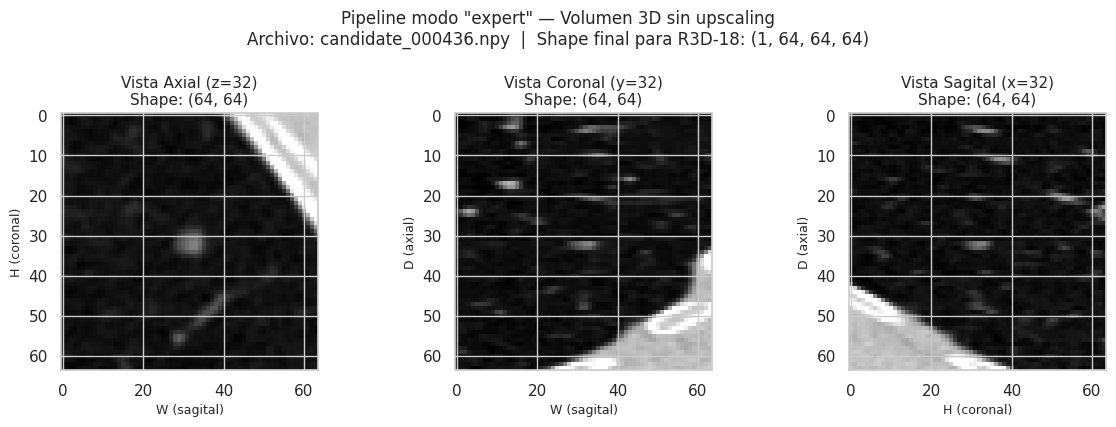

In [160]:
# ── Visualización del pipeline modo "expert" (volumen 3D para MC3-18) ─────────────
if len(pos_examples) > 0:
    volume_3d = np.load(pos_examples[0])
    
    print("Pipeline modo 'expert' — volumen 3D para MC3-18:")
    print("=" * 60)
    print(f"  Shape entrada (.npy):  {volume_3d.shape}  → dtype: {volume_3d.dtype}")
    print(f"  Rango de valores:      [{volume_3d.min():.4f}, {volume_3d.max():.4f}]")
    print(f"  Shape para MC3-18:     (1, 64, 64, 64)  [canal, D, H, W]")
    print(f"  Sin resize — MC3-18 acepta volúmenes 64³")
    print(f"  Sin normalización ImageNet (datos médicos monocanal)")
    print()
    
    # Visualizar las 3 vistas del volumen 3D SIN upscaling
    mid = volume_3d.shape[0] // 2  # = 32
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    axes[0].imshow(volume_3d[mid, :, :], cmap='gray', vmin=0, vmax=1)
    axes[0].set_title(f'Vista Axial (z={mid})\nShape: {volume_3d[mid,:,:].shape}', fontsize=11)
    axes[0].set_xlabel('W (sagital)', fontsize=9)
    axes[0].set_ylabel('H (coronal)', fontsize=9)
    
    axes[1].imshow(volume_3d[:, mid, :], cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(f'Vista Coronal (y={mid})\nShape: {volume_3d[:,mid,:].shape}', fontsize=11)
    axes[1].set_xlabel('W (sagital)', fontsize=9)
    axes[1].set_ylabel('D (axial)', fontsize=9)
    
    axes[2].imshow(volume_3d[:, :, mid], cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f'Vista Sagital (x={mid})\nShape: {volume_3d[:,:,mid].shape}', fontsize=11)
    axes[2].set_xlabel('H (coronal)', fontsize=9)
    axes[2].set_ylabel('D (axial)', fontsize=9)
    
    plt.suptitle(
        f'Pipeline modo "expert" — Volumen 3D sin upscaling\n'
                 f'Archivo: {pos_examples[0].name}  |  Shape final para MC3-18: (1, 64, 64, 64)',
        fontsize=12, y=1.02
    )
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'sec7_expert_pipeline_3d.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Sin ejemplos positivos disponibles para el pipeline expert.")

---
## Sección 8 — Verificación de Integridad del Split

El split es a nivel de **serie CT** (`seriesuid`), no a nivel de parche.
Esto previene la fuga de datos: todos los parches de una misma tomografía
pertenecen al mismo split.

In [161]:
# ── Load and validate splits ────────────────────────────────────
if SPLITS_JSON.exists():
    with open(SPLITS_JSON) as f:
        splits_data = json.load(f)

    train_uids = set(splits_data.get('train_uids', []))
    val_uids   = set(splits_data.get('val_uids', []))
    test_uids  = set(splits_data.get('test_uids', []))

    print(f'Split sizes (from luna_splits.json):')
    print(f'  Train: {len(train_uids)} series')
    print(f'  Val:   {len(val_uids)} series')
    print(f'  Test:  {len(test_uids)} series')
    print(f'  Total: {len(train_uids) + len(val_uids) + len(test_uids)} series')

    # Check for overlaps
    tv_overlap = train_uids & val_uids
    tt_overlap = train_uids & test_uids
    vt_overlap = val_uids & test_uids

    print(f'\nOverlap check (must all be 0):')
    print(f'  Train ∩ Val:  {len(tv_overlap)}')
    print(f'  Train ∩ Test: {len(tt_overlap)}')
    print(f'  Val ∩ Test:   {len(vt_overlap)}')

    if len(tv_overlap) == 0 and len(tt_overlap) == 0 and len(vt_overlap) == 0:
        print(f'\n  PASS: No data leakage — splits are at series level with zero overlap.')
    else:
        print(f'\n  FAIL: Data leakage detected! Overlapping series found.')

    # Compare against total available series
    all_split_uids = train_uids | val_uids | test_uids
    all_candidate_uids = set(df_cand['seriesuid'].unique())
    missing_from_splits = all_candidate_uids - all_split_uids
    extra_in_splits = all_split_uids - all_candidate_uids
    print(f'\nCoverage:')
    print(f'  Series in candidates_V2 not in any split: {len(missing_from_splits)}')
    print(f'  Series in splits not in candidates_V2:    {len(extra_in_splits)}')
else:
    print(f'WARNING: luna_splits.json not found at {SPLITS_JSON}')
    splits_data = None

Split sizes (from luna_splits.json):
  Train: 712 series
  Val:   88 series
  Test:  88 series
  Total: 888 series

Overlap check (must all be 0):
  Train ∩ Val:  0
  Train ∩ Test: 0
  Val ∩ Test:   0

  PASS: No data leakage — splits are at series level with zero overlap.

Coverage:
  Series in candidates_V2 not in any split: 0
  Series in splits not in candidates_V2:    0


### Visualización de proporciones del split

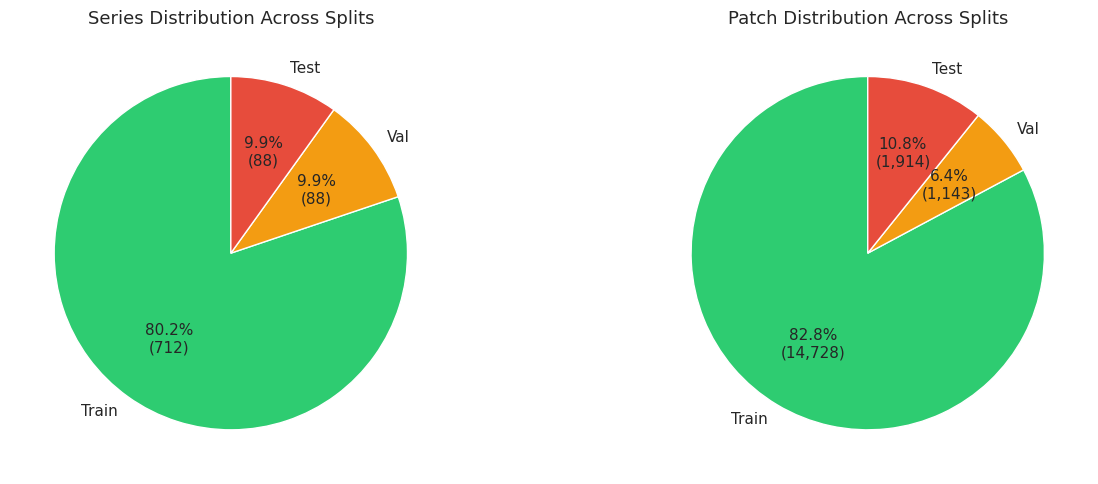

In [162]:
# ── Visualize split proportions ──────────────────────────────────
if SPLITS_JSON.exists():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Series per split
    split_names = ['Train', 'Val', 'Test']
    series_counts = [len(train_uids), len(val_uids), len(test_uids)]
    colors = ['#2ecc71', '#f39c12', '#e74c3c']

    axes[0].pie(series_counts, labels=split_names, colors=colors,
                autopct=lambda p: f'{p:.1f}%\n({int(p/100*sum(series_counts))})',
                startangle=90, textprops={'fontsize': 11})
    axes[0].set_title('Series Distribution Across Splits', fontsize=13)

    # Patches per split
    patch_counts = [split_counts.get('train', 0), split_counts.get('val', 0),
                    split_counts.get('test', 0)]
    axes[1].pie(patch_counts, labels=split_names, colors=colors,
                autopct=lambda p: f'{p:.1f}%\n({int(p/100*sum(patch_counts)):,})',
                startangle=90, textprops={'fontsize': 11})
    axes[1].set_title('Patch Distribution Across Splits', fontsize=13)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'sec8_split_proportions.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Sección 9 — Riesgo de Overfitting y Decisión de Arquitectura

Con solo 14.728 muestras de entrenamiento, la elección del modelo es crítica.

### Análisis de ratio parámetros / muestras

El ratio **parámetros del modelo / muestras de entrenamiento** es el indicador
principal de riesgo de overfitting (junto con la regularización disponible):

| Arquitectura | Parámetros | Ratio params/muestras | Decisión |
|-------------|------------|----------------------|----------|
| ViViT-Tiny (spec original) | ~25.3 M | ~1.718:1 → **2.038:1** con desbalance | ❌ RECHAZADO |
| MC3-18 (alternativa adoptada) | ~11.2 M | **~761:1** con augmentation | ✅ ADOPTADO |

> **Criterio de decisión:**
> - Ratio > 1.000:1 sin augmentation → alto riesgo de memorización
> - ViViT-Tiny: ratio efectivo ~2.038:1 (considerando ~1.258 positivos útiles)
>   → La red memorizaría los 1.258 nódulos sin generalizar
> - MC3-18 (~11.2M params) con augmentation 3D agresivo → ratio 761:1 → aceptable
>
> Ver `src/pipeline/fase2/expert3_config.py` para los hiperparámetros definitivos.

In [163]:
# ── Tabla comparativa de arquitecturas para Expert 3 ─────────────────────────
import textwrap

print("Análisis de riesgo de overfitting — Expert 3 (LUNA16)")
print("=" * 70)
print()

n_train = 14728
n_pos = 1258
n_neg = 13470

print(f"Dataset de entrenamiento:")
print(f"  Total muestras:    {n_train:,}")
print(f"  Positivos (nódulos): {n_pos:,}")
print(f"  Negativos:           {n_neg:,}")
print(f"  Ratio neg:pos:       {n_neg/n_pos:.1f}:1")
print()

architectures = [
    ("ViViT-Tiny (spec original)", 25_300_000, "RECHAZADO"),
    ("MC3-18 (adoptado)",          11_200_000, "ADOPTADO"),
]

print(f"{'Arquitectura':<32} {'Params':>12} {'Ratio params/train':>20} {'Decisión':>12}")
print("-" * 80)
for name, params, decision in architectures:
    ratio = params / n_train
    flag = "❌" if decision == "RECHAZADO" else "✅"
    print(f"{name:<32} {params:>12,} {ratio:>17.0f}:1  {flag} {decision}")

print()
print("Referencia literatura LUNA16:")
print("  - LUNA16 challenge winners: modelos <15M params con augmentation 3D")
print("  - Ratio < 1000:1 con regularización fuerte → aceptable para datos médicos")
print()
print("Configuración final (src/pipeline/fase2/expert3_config.py):")
print("  LR=3e-4 | WD=0.03 | dropout_fc=0.4 | spatial_dropout3d=0.15")
print("  FocalLoss(γ=2, α=0.85) | batch_efectivo=32 | FP16=True | patience=20")

Análisis de riesgo de overfitting — Expert 3 (LUNA16)

Dataset de entrenamiento:
  Total muestras:    14,728
  Positivos (nódulos): 1,258
  Negativos:           13,470
  Ratio neg:pos:       10.7:1

Arquitectura                           Params   Ratio params/train     Decisión
--------------------------------------------------------------------------------
ViViT-Tiny (spec original)         25,300,000              1718:1  ❌ RECHAZADO
MC3-18 (adoptado)                  11,200,000               760:1  ✅ ADOPTADO

Referencia literatura LUNA16:
  - LUNA16 challenge winners: modelos <15M params con augmentation 3D
  - Ratio < 1000:1 con regularización fuerte → aceptable para datos médicos

Configuración final (src/pipeline/fase2/expert3_config.py):
  LR=3e-4 | WD=0.03 | dropout_fc=0.4 | spatial_dropout3d=0.15
  FocalLoss(γ=2, α=0.85) | batch_efectivo=32 | FP16=True | patience=20


---
## Sección 10 — Augmentation 3D (modo expert, solo train)

El augmentation 3D es obligatorio dado el ratio desfavorable parámetros/muestras.
Se aplica **únicamente** en `mode="expert"` + `split="train"` (ver `luna.py`).

### Las 4 transformaciones implementadas:

| # | Transformación | Parámetros | Justificación |
|---|---------------|-----------|---------------|
| 1 | **Flip aleatorio** en 3 ejes (D, H, W) | P=0.5 por eje | Los nódulos no tienen orientación preferida |
| 2 | **Rotación axial** (plano H×W) | ±15°, orden bilineal | Variación de posicionamiento del paciente |
| 3 | **Variación de intensidad HU** | offset∈[-20,+20] HU, escala∈[0.95,1.05] | Simula diferencias inter-scanner |
| 4 | **Ruido gaussiano** | σ~U(0, 0.02), P=0.3 | Simula ruido de adquisición CT |

> Implementación completa en `src/pipeline/datasets/luna.py` → método `_augment_3d()`.

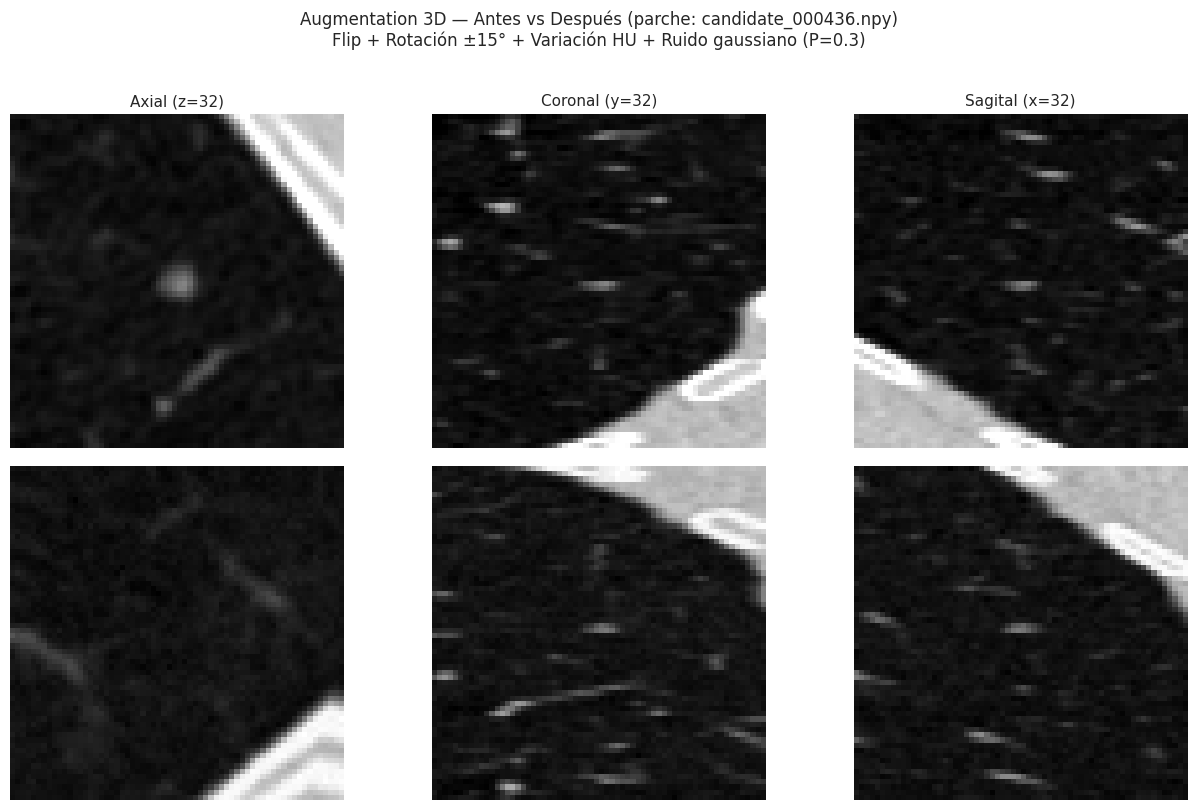

Volumen original:    shape=(64, 64, 64), rango=[0.0000, 1.0000]
Volumen augmentado:  shape=(64, 64, 64),  rango=[-0.0301, 1.0210]


In [164]:
# ── Demostración de augmentation 3D en parche positivo ───────────────────────
import random
from scipy.ndimage import rotate as scipy_rotate

def augment_3d_demo(volume: np.ndarray, seed: int = 42) -> np.ndarray:
    """Replica simplificada de _augment_3d() de luna.py para demo en EDA."""
    random.seed(seed)
    np.random.seed(seed)
    vol = volume.copy().astype(np.float32)
    
    # 1. Flip aleatorio en 3 ejes con P=0.5
    for axis in range(3):
        if random.random() < 0.5:
            vol = np.flip(vol, axis=axis)
    
    # 2. Rotación ±15° en eje axial
    angle = random.uniform(-15.0, 15.0)
    if abs(angle) > 0.5:
        vol = scipy_rotate(vol, angle=angle, axes=(1, 2),
                           reshape=False, order=1, mode='nearest')
    
    # 3. Variación de intensidad HU
    offset_hu = random.uniform(-20.0, 20.0)
    scale = random.uniform(0.95, 1.05)
    offset_norm = offset_hu / 1400.0
    vol = vol * scale + offset_norm
    
    # 4. Ruido gaussiano con P=0.3
    if random.random() < 0.3:
        sigma = random.uniform(0.0, 0.02)
        vol = vol + np.random.normal(0.0, sigma, vol.shape).astype(np.float32)
    
    return np.ascontiguousarray(vol, dtype=np.float32)


if len(pos_examples) > 0:
    vol_orig = np.load(pos_examples[0])
    vol_aug  = augment_3d_demo(vol_orig, seed=7)
    mid = vol_orig.shape[0] // 2
    
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    
    views_orig = [vol_orig[mid,:,:], vol_orig[:,mid,:], vol_orig[:,:,mid]]
    views_aug  = [vol_aug[mid,:,:],  vol_aug[:,mid,:],  vol_aug[:,:,mid]]
    view_names = ['Axial (z=32)', 'Coronal (y=32)', 'Sagital (x=32)']
    
    for col, (v_orig, v_aug, vname) in enumerate(zip(views_orig, views_aug, view_names)):
        # Fila 0: original
        axes[0, col].imshow(v_orig, cmap='gray', vmin=0, vmax=1)
        axes[0, col].set_title(vname, fontsize=11)
        if col == 0:
            axes[0, col].set_ylabel('ORIGINAL', fontsize=12, fontweight='bold',
                                    rotation=90, labelpad=10)
        axes[0, col].axis('off')
        
        # Fila 1: augmentado
        axes[1, col].imshow(v_aug, cmap='gray')
        if col == 0:
            axes[1, col].set_ylabel('AUGMENTADO', fontsize=12, fontweight='bold',
                                    rotation=90, labelpad=10)
        axes[1, col].axis('off')
    
    plt.suptitle(
        f'Augmentation 3D — Antes vs Después (parche: {pos_examples[0].name})\n'
        f'Flip + Rotación ±15° + Variación HU + Ruido gaussiano (P=0.3)',
        fontsize=12, y=1.01
    )
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'sec10_augmentation_demo.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Volumen original:    shape={vol_orig.shape}, "
          f"rango=[{vol_orig.min():.4f}, {vol_orig.max():.4f}]")
    print(f"Volumen augmentado:  shape={vol_aug.shape},  "
          f"rango=[{vol_aug.min():.4f}, {vol_aug.max():.4f}]")
else:
    print("Sin ejemplos positivos para la demo de augmentation.")

---
## Sección 11 — Resumen de Hallazgos Clave

> ⚠️ **Este resumen refleja el estado POST-FIX W-03 (2026-04-02).**

### Resumen del Dataset
| Propiedad | Valor |
|-----------|-------|
| Anatomía | **Tórax** — CT pulmonar (LUNA16 / LIDC-IDRI) |
| Volúmenes CT totales | 888 (10 subsets) |
| Candidatos totales (V2) | 754.975 |
| Candidatos positivos (nódulos) | 1.557 |
| Candidatos negativos | 753.418 |
| Ratio de desbalance bruto | ~484:1 |
| Nódulos anotados (con diámetro) | 1.186 |

### Parches Pre-extraídos (post-fix W-03)
| Split | Total | Positivos | Negativos | Ratio |
|-------|-------|-----------|-----------|-------|
| Train | 14.728 | ~1.258 | ~13.470 | ~10.7:1 |
| Val   | 1.143  | ~105   | ~1.038  | ~9.9:1  |
| Test  | 1.914  | ~174   | ~1.740  | ~10.0:1 |

### Propiedades Confirmadas
- **Forma del parche:** `(64, 64, 64)` — volúmenes 3D en escala de grises
- **Rango de valores:** `[0.0, 1.0]` — clip HU [-1000, 400] + normalización aplicada
- **Dtype:** `float32`
- **Espaciado CT:** Variable, especialmente en eje Z (grosor de slice varía entre scanners)

### Integridad del Split
- Splits a nivel de **serie CT** — sin solapamiento de `seriesuid` entre train/val/test
- 712 series train / 88 series val / 88 series test
- Fuga de datos remediada: 1.839 parches de fuga eliminados (W-03, 2026-04-02)

### Decisiones Técnicas Críticas
1. **FocalLoss(γ=2, α=0.85)** — alpha corregido de 0.25 a 0.85 (n_neg/n_total ≈ 0.915)
2. **Arquitectura: MC3-18** (~11.2M params) — ViViT-Tiny rechazado por ratio 2.038:1
3. **Augmentation 3D** (flip×3, rot±15°, var-HU, ruido) — crítico con ratio 761:1
4. **Submuestreo 10:1 por split** — correcto, no global
5. **Pipeline dual:**
   - `mode="embedding"` → 3 slices 2D + resize 224×224 + ImageNet-norm → Fase 1
   - `mode="expert"` → volumen 3D `[1,64,64,64]` sin resize → MC3-18 Fase 2
6. **Métrica de evaluación:** CPM + curva FROC con `noduleCADEvaluationLUNA16.py`